In [1]:
!pip install yfinance
!pip install feedparser
!pip install vaderSentiment
!pip install praw

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.3 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=3310145b816b29fd0def2738bae43aa154826b65558987e40d1cb7529b993ee2
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 6.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import feedparser
import requests
import datetime

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [8]:
import yfinance as yf

stock = yf.download(
    "AAPL",
    start="2023-01-01",
    end="2025-01-01",
    auto_adjust=True
)

print(stock.head())

print("Rows:", len(stock))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500
2023-01-04  124.365685  126.629387  123.105888  124.887318   89113600
2023-01-05  123.046799  125.753395  122.790908  125.123497   80962700
2023-01-06  127.574226  128.233650  122.918883  124.021209   87754700
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800
Rows: 502


In [19]:
import feedparser

rss_url = "https://feeds.finance.yahoo.com/rss/2.0/headline?s=AAPL&region=US&lang=en-US"

feed = feedparser.parse(rss_url)

headlines = []

for entry in feed.entries:

    headlines.append(entry.title)

print("Total Headlines:", len(headlines))

print(headlines[:10])

Total Headlines: 20
['Apple dominated the 2026 chip war. Google’s partners are left to buy scraps', 'Apple Intel Chip Deal Reshapes Supply Chain And Valuation Debate', "1 Reason You'll Regret Not Buying Apple Stock Now", 'Energy Fund Yielding 7% and Up 14% in a Year Still Wasn’t Enough to Stop This $3 Million Exit', 'Why a Major Investor Dumped $32 Million of This 7.2% Yielding Closed-End Fund', "Warren Buffett's McLane makes major bet on driverless big rigs", 'Dow Jones Futures: Market At Highs With Iran, Trump-Xi Summit In Focus; Apple, Nvidia, Boeing In Buy Areas', "The Nasdaq's top winners are now running hotter than in 2000: Chart of the Day", 'This $2.9 billion fund has paid distributions for 26 straight years', 'MP Materials Apple Deal Recasts Rare Earth Miner As Integrated Magnet Supplier']


In [20]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

sentiments = []

for text in headlines:

    score = analyzer.polarity_scores(text)['compound']

    if score > 0.05:
        sentiment = 1

    elif score < -0.05:
        sentiment = -1

    else:
        sentiment = 0

    sentiments.append(sentiment)

news_df = pd.DataFrame({
    'headline': headlines,
    'sentiment': sentiments
})

print(news_df.head())

print("Total News:", len(news_df))

                                            headline  sentiment
0  Apple dominated the 2026 chip war. Google’s pa...         -1
1  Apple Intel Chip Deal Reshapes Supply Chain An...          0
2  1 Reason You'll Regret Not Buying Apple Stock Now         -1
3  Energy Fund Yielding 7% and Up 14% in a Year S...          0
4  Why a Major Investor Dumped $32 Million of Thi...         -1
Total News: 20


In [21]:
average_sentiment = np.mean(sentiments)

stock['Sentiment'] = average_sentiment

stock['Target'] = np.where(
    stock['Close'].shift(-1) > stock['Close'],
    1,
    0
)

# Remove last empty row only
stock = stock[:-1]

print(stock.head())

print("Rows after processing:", len(stock))

Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500   
2023-01-04  124.365685  126.629387  123.105888  124.887318   89113600   
2023-01-05  123.046799  125.753395  122.790908  125.123497   80962700   
2023-01-06  127.574226  128.233650  122.918883  124.021209   87754700   
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800   

Price      Sentiment Target  
Ticker                       
Date                         
2023-01-03       0.2      1  
2023-01-04       0.2      0  
2023-01-05       0.2      1  
2023-01-06       0.2      1  
2023-01-09       0.2      1  
Rows after processing: 500


In [22]:
scaler = MinMaxScaler()

data = stock[['Close', 'Sentiment']]

print(data.head())

scaled_data = scaler.fit_transform(data)

X = []
y = []

sequence_length = 10

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i])

    y.append(stock['Target'].iloc[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Price            Close Sentiment
Ticker            AAPL          
Date                            
2023-01-03  123.096031       0.2
2023-01-04  124.365685       0.2
2023-01-05  123.046799       0.2
2023-01-06  127.574226       0.2
2023-01-09  128.095840       0.2
X shape: (490, 10, 2)
y shape: (490,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (392, 10, 2)
Testing Data: (98, 10, 2)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        50,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5357 - loss: 0.6945 - val_accuracy: 0.6020 - val_loss: 0.6816
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5510 - loss: 0.6945 - val_accuracy: 0.6020 - val_loss: 0.6846
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5128 - loss: 0.6937 - val_accuracy: 0.6020 - val_loss: 0.6823
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5510 - loss: 0.6866 - val_accuracy: 0.6020 - val_loss: 0.6723
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5510 - loss: 0.6940 - val_accuracy: 0.6020 - val_loss: 0.6776
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5510 - loss: 0.6901 - val_accuracy: 0.6020 - val_loss: 0.6743
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5510 - loss: 0.6896 - val_accuracy: 0.6020 - val_loss: 0.6798
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5510 - loss: 0.6884 - val_accuracy: 0.6020 - val_loss: 0.6746
Ep

In [25]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        50,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5255 - loss: 0.6917 - val_accuracy: 0.6020 - val_loss: 0.6773
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5510 - loss: 0.6894 - val_accuracy: 0.6020 - val_loss: 0.6730
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5510 - loss: 0.6889 - val_accuracy: 0.6020 - val_loss: 0.6753
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5510 - loss: 0.6892 - val_accuracy: 0.6020 - val_loss: 0.6740
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5510 - loss: 0.6893 - val_accuracy: 0.6020 - val_loss: 0.6737
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5510 - loss: 0.6894 - val_accuracy: 0.6020 - val_loss: 0.6734
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5510 - loss: 0.6886 - val_accuracy: 0.6020 - val_loss: 0.6774
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5510 - loss: 0.6887 - val_accuracy: 0.6020 - val_loss

In [26]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(
    GRU(
        50,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5510 - loss: 0.6908 - val_accuracy: 0.6020 - val_loss: 0.6726
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5510 - loss: 0.6887 - val_accuracy: 0.6020 - val_loss: 0.6744
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5510 - loss: 0.6893 - val_accuracy: 0.6020 - val_loss: 0.6755
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5510 - loss: 0.6890 - val_accuracy: 0.6020 - val_loss: 0.6743
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5510 - loss: 0.6892 - val_accuracy: 0.6020 - val_loss: 0.6726
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5510 - loss: 0.6893 - val_accuracy: 0.6020 - val_loss: 0.6756
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5510 - loss: 0.6886 - val_accuracy: 0.6020 - val_loss: 0.6741
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5510 - loss: 0.6894 - val_accuracy: 0.6020 - v

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

def evaluate_model(model, name):

    predictions = model.predict(X_test)

    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    print("\n====================")
    print(name)
    print("====================")

    print("Accuracy:", accuracy)

    print("F1 Score:", f1)

    print("\nClassification Report:\n")

    print(classification_report(y_test, predictions))

evaluate_model(rnn_model, "RNN Model")

evaluate_model(lstm_model, "LSTM Model")

evaluate_model(gru_model, "GRU Model")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

RNN Model
Accuracy: 0.6020408163265306
F1 Score: 0.7515923566878981

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.60      1.00      0.75        59

    accuracy                           0.60        98
   macro avg       0.30      0.50      0.38        98
weighted avg       0.36      0.60      0.45        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

LSTM Model
Accuracy: 0.6020408163265306
F1 Score: 0.7515923566878981

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.60      1.00      0.75        59

    accuracy                           0.60        98
   macro avg       0.30      0.50      0.38        98
weighted avg       0.36      0.60      0.45        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

GRU Model
Accuracy: 0.6020408163265306
F1 Score: 0.7515923566878981

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.60      1.00      0.75        59

    accuracy                           0.60        98
   macro avg       0.30      0.50      0.38        98
weighted avg       0.36      0.60      0.45        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
rnn_pred = (rnn_model.predict(X_test) > 0.5).astype(int)
lstm_pred = (lstm_model.predict(X_test) > 0.5).astype(int)
gru_pred = (gru_model.predict(X_test) > 0.5).astype(int)

rnn_acc = accuracy_score(y_test, rnn_pred)
lstm_acc = accuracy_score(y_test, lstm_pred)
gru_acc = accuracy_score(y_test, gru_pred)

print("\nFinal Comparison")

print("RNN Accuracy :", rnn_acc)

print("LSTM Accuracy:", lstm_acc)

print("GRU Accuracy :", gru_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Final Comparison
RNN Accuracy : 0.6020408163265306
LSTM Accuracy: 0.6020408163265306
GRU Accuracy : 0.6020408163265306


In [29]:
latest_data = X_test[-1]

latest_data = np.expand_dims(latest_data, axis=0)

prediction = lstm_model.predict(latest_data)

print("Prediction Value:", prediction)

if prediction > 0.5:
    print("Market Direction: UP")
else:
    print("Market Direction: DOWN")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction Value: [[0.5701659]]
Market Direction: UP


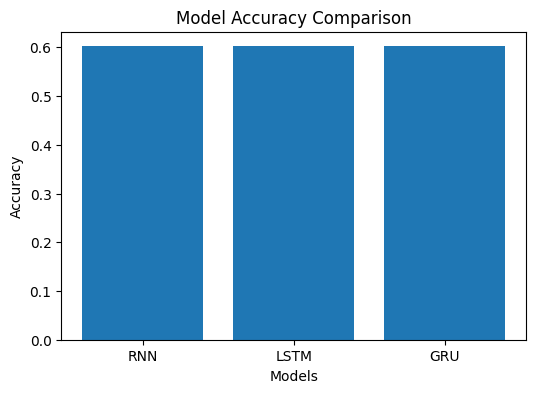

In [30]:
import matplotlib.pyplot as plt

models = ['RNN', 'LSTM', 'GRU']

accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()